# 1. Инициализация проекта

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 1.1. Чтение данных

In [2]:
data = pd.read_csv(r'D:\Python\OmSTU\NLP\lab_1\data\card_transdata.csv')

## 1.2. Исследование исходных данных

In [3]:
data.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 8 columns):
 #   Column                          Non-Null Count    Dtype  
---  ------                          --------------    -----  
 0   distance_from_home              1000000 non-null  float64
 1   distance_from_last_transaction  1000000 non-null  float64
 2   ratio_to_median_purchase_price  1000000 non-null  float64
 3   repeat_retailer                 1000000 non-null  float64
 4   used_chip                       1000000 non-null  float64
 5   used_pin_number                 1000000 non-null  float64
 6   online_order                    1000000 non-null  float64
 7   fraud                           1000000 non-null  float64
dtypes: float64(8)
memory usage: 61.0 MB


In [4]:
data.head(10)

,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price,repeat_retailer,used_chip,used_pin_number,online_order,fraud
0,57.877857,0.311140,1.945940,1.0,1.0,0.0,0.0,0.0
1,10.829943,0.175592,1.294219,1.0,0.0,0.0,0.0,0.0
2,5.091079,0.805153,0.427715,1.0,0.0,0.0,1.0,0.0
3,2.247564,5.600044,0.362663,1.0,1.0,0.0,1.0,0.0
4,44.190936,0.566486,2.222767,1.0,1.0,0.0,1.0,0.0
5,5.586408,13.261073,0.064768,1.0,0.0,0.0,0.0,0.0
6,3.724019,0.956838,0.278465,1.0,0.0,0.0,1.0,0.0
7,4.848247,0.320735,1.273050,1.0,0.0,1.0,0.0,0.0
8,0.876632,2.503609,1.516999,0.0,0.0,0.0,0.0,0.0
9,8.839047,2.970512,2.361683,1.0,0.0,0.0,1.0,0.0


**Поля таблицы:**
- Расстояние от дома
- Расстояние от последней транзакции
- Отношение к средней цене покупки
- Постоянный продавец
- Использовался чип
- Использовался пин-код
- Онлайн заказ
- Мошенническая ли транзакция

**Характеристика исходных данных:**
- Первые три столбца имеют данные типа float64, что соответствует установленному типу
- Последние пять столбцов необходимо перевести в int8 тип

## 1.3. Выводы и дальнейшие шаги

In [5]:
data.describe()

,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price,repeat_retailer,used_chip,used_pin_number,online_order,fraud
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000
mean,26.628792,5.036519,1.824182,0.881536,0.350399,0.100608,0.650552,0.087403
std,65.390784,25.843093,2.799589,0.323157,0.477095,0.300809,0.476796,0.282425
min,0.004874,0.000118,0.004399,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.878008,0.296671,0.475673,1.000000,0.000000,0.000000,0.000000,0.000000
50%,9.967760,0.998650,0.997717,1.000000,0.000000,0.000000,1.000000,0.000000
75%,25.743985,3.355748,2.096370,1.000000,1.000000,0.000000,1.000000,0.000000
max,10632.723672,11851.104565,267.802942,1.000000,1.000000,1.000000,1.000000,1.000000


**Вывод:**
- Нулевые (пропущенные) значения отсутствуют
- Для более читаемых результатов с данными необходимо ещё поработать

# 2. Обработка пропущенных значений

In [6]:
(data.isna().sum()/data.shape[0]*100).sort_values(ascending=False)

distance_from_home                0.0
distance_from_last_transaction    0.0
ratio_to_median_purchase_price    0.0
repeat_retailer                   0.0
used_chip                         0.0
used_pin_number                   0.0
online_order                      0.0
fraud                             0.0
dtype: float64

Пропущенные значения **отсутствуют**

# 3. Коррекция типов данных

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 8 columns):
 #   Column                          Non-Null Count    Dtype  
---  ------                          --------------    -----  
 0   distance_from_home              1000000 non-null  float64
 1   distance_from_last_transaction  1000000 non-null  float64
 2   ratio_to_median_purchase_price  1000000 non-null  float64
 3   repeat_retailer                 1000000 non-null  float64
 4   used_chip                       1000000 non-null  float64
 5   used_pin_number                 1000000 non-null  float64
 6   online_order                    1000000 non-null  float64
 7   fraud                           1000000 non-null  float64
dtypes: float64(8)
memory usage: 61.0 MB


In [8]:
data['repeat_retailer'] = data['repeat_retailer'].astype('Int8')
data['used_chip'] = data['used_chip'].astype('Int8')
data['used_pin_number'] = data['used_pin_number'].astype('Int8')
data['online_order'] = data['online_order'].astype('Int8')
data['fraud'] = data['fraud'].astype('Int8')
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 8 columns):
 #   Column                          Non-Null Count    Dtype  
---  ------                          --------------    -----  
 0   distance_from_home              1000000 non-null  float64
 1   distance_from_last_transaction  1000000 non-null  float64
 2   ratio_to_median_purchase_price  1000000 non-null  float64
 3   repeat_retailer                 1000000 non-null  Int8   
 4   used_chip                       1000000 non-null  Int8   
 5   used_pin_number                 1000000 non-null  Int8   
 6   online_order                    1000000 non-null  Int8   
 7   fraud                           1000000 non-null  Int8   
dtypes: Int8(5), float64(3)
memory usage: 32.4 MB


# 4. Обогащение данных

In [9]:
# дубликаты не нужны так как не несут новой информации
data.drop_duplicates(inplace=True)

Так как текстовых данных не предоставлено - как-либо ещё обогатить данные не получится

# 5. Проверка данных

In [10]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 8 columns):
 #   Column                          Non-Null Count    Dtype  
---  ------                          --------------    -----  
 0   distance_from_home              1000000 non-null  float64
 1   distance_from_last_transaction  1000000 non-null  float64
 2   ratio_to_median_purchase_price  1000000 non-null  float64
 3   repeat_retailer                 1000000 non-null  Int8   
 4   used_chip                       1000000 non-null  Int8   
 5   used_pin_number                 1000000 non-null  Int8   
 6   online_order                    1000000 non-null  Int8   
 7   fraud                           1000000 non-null  Int8   
dtypes: Int8(5), float64(3)
memory usage: 32.4 MB


In [11]:
data.head(10)

,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price,repeat_retailer,used_chip,used_pin_number,online_order,fraud
0,57.877857,0.311140,1.945940,1,1,0,0,0
1,10.829943,0.175592,1.294219,1,0,0,0,0
2,5.091079,0.805153,0.427715,1,0,0,1,0
3,2.247564,5.600044,0.362663,1,1,0,1,0
4,44.190936,0.566486,2.222767,1,1,0,1,0
5,5.586408,13.261073,0.064768,1,0,0,0,0
6,3.724019,0.956838,0.278465,1,0,0,1,0
7,4.848247,0.320735,1.273050,1,0,1,0,0
8,0.876632,2.503609,1.516999,0,0,0,0,0
9,8.839047,2.970512,2.361683,1,0,0,1,0


Данные выглядят **чистыми** и **информативными**

# 6. Исследование основных параметров

In [12]:
data.describe()

,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price,repeat_retailer,used_chip,used_pin_number,online_order,fraud
count,1000000.000000,1000000.000000,1000000.000000,1000000.0,1000000.0,1000000.0,1000000.0,1000000.0
mean,26.628792,5.036519,1.824182,0.881536,0.350399,0.100608,0.650552,0.087403
std,65.390784,25.843093,2.799589,0.323157,0.477095,0.300809,0.476796,0.282425
min,0.004874,0.000118,0.004399,0.0,0.0,0.0,0.0,0.0
25%,3.878008,0.296671,0.475673,1.0,0.0,0.0,0.0,0.0
50%,9.967760,0.998650,0.997717,1.0,0.0,0.0,1.0,0.0
75%,25.743985,3.355748,2.096370,1.0,1.0,0.0,1.0,0.0
max,10632.723672,11851.104565,267.802942,1.0,1.0,1.0,1.0,1.0


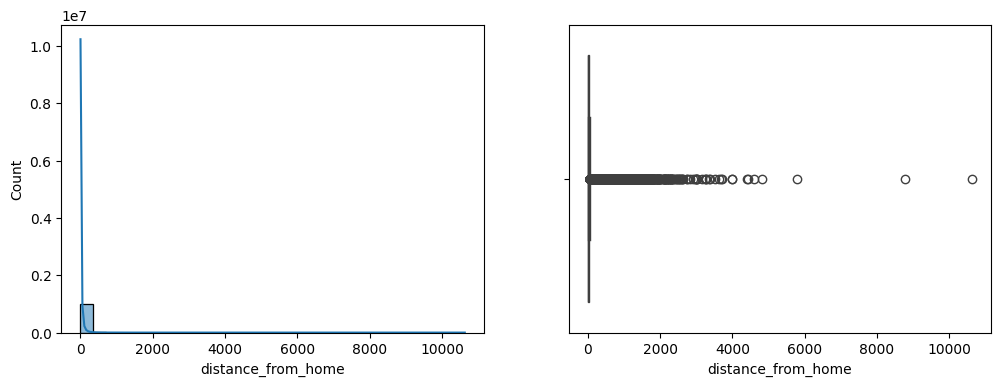

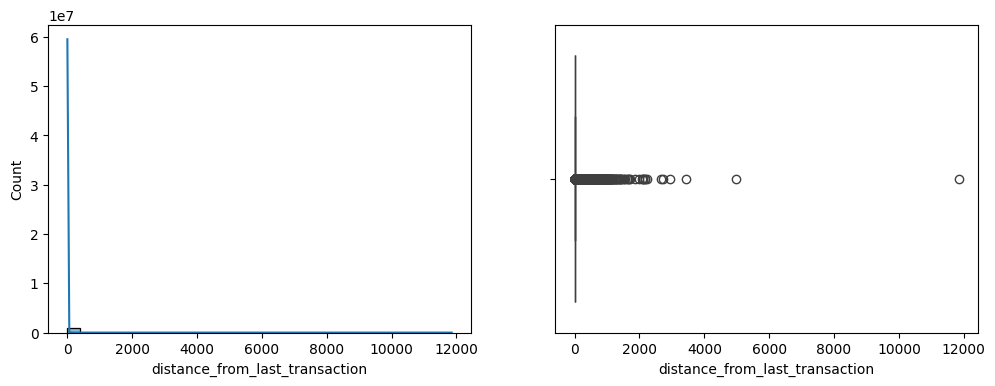

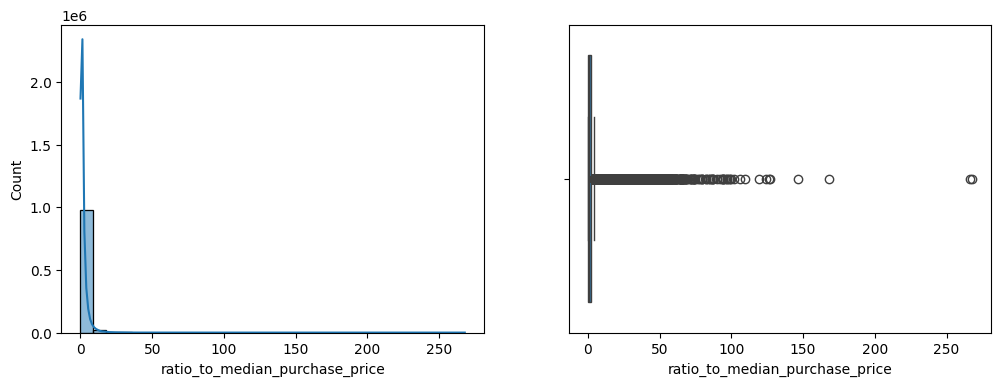

In [13]:
columns = ['distance_from_home', 'distance_from_last_transaction', 'ratio_to_median_purchase_price']

for col in columns:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    sns.histplot(data[col], bins=30, kde=True, ax=axes[0])
    sns.boxplot(x=data[col], ax=axes[1])
    plt.show()

Выводы:
- Тяжело оценить данные по графикам
- Основная доля данных имеет небольшие величины

# 7. Изучение и обработка выбросов

В контексте предметной области _на мой взгляд_ все значения важны, ведь, вероятно, в аномально больших значениях (например расстояние от последней транзакции) и кроется ключ к определению мошеннеческой операции

# 8. Анализ корреляции информации об операции с информацией о том является ли она мошеннической

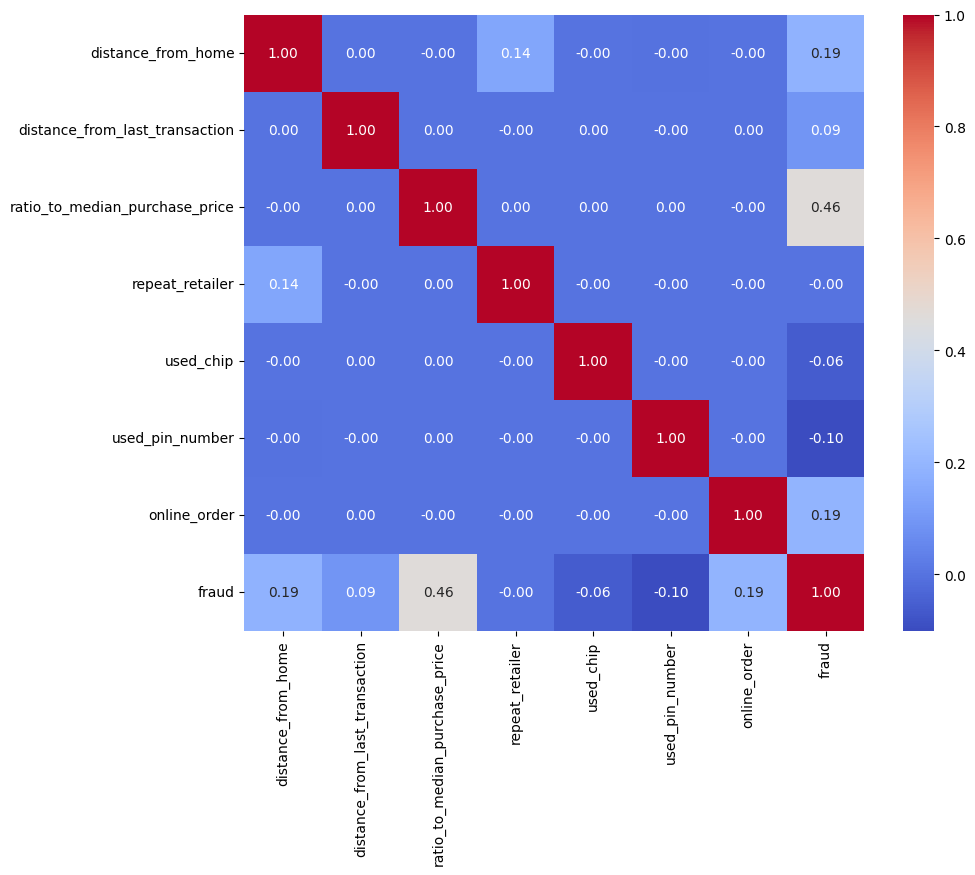

In [14]:
plt.figure(figsize=(10, 8))
sns.heatmap(data.corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.show()

In [15]:
data.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 8 columns):
 #   Column                          Non-Null Count    Dtype  
---  ------                          --------------    -----  
 0   distance_from_home              1000000 non-null  float64
 1   distance_from_last_transaction  1000000 non-null  float64
 2   ratio_to_median_purchase_price  1000000 non-null  float64
 3   repeat_retailer                 1000000 non-null  Int8   
 4   used_chip                       1000000 non-null  Int8   
 5   used_pin_number                 1000000 non-null  Int8   
 6   online_order                    1000000 non-null  Int8   
 7   fraud                           1000000 non-null  Int8   
dtypes: Int8(5), float64(3)
memory usage: 32.4 MB


# Вывод

**Ход работы:**
1. Знакомство с данными
2. Работа с пропущенными данными
3. Коррекция типов
4. Обогащение данных
5. Проверка данных
6. Исследование основных параметров
7. Исследование и обработка выбросов
8. Анализ корреляции информации об операции с информацией о том является ли она мошеннической

**Полученные результаты:**
- Память, занимаемая датасетом уменьшена **вдвое** без потери информативности
- Замечена корреляция между практически всеми признаками

In [16]:
data.to_csv(r'D:\Python\OmSTU\NLP\lab_1\data\post_card_transdata.csv', index=False)